In [12]:
import duckdb

In [ ]:

with duckdb.connect('../pipelines/duckdb/dev.duckdb') as con:
  df_anomalies = con.sql('''
  with cte_group_issues as (
  select
    issue_type
    , date(issue_start_dtt) issue_date
    , count(*)
    as issue_count
  from gold.dim_cx_issue
  group by issue_type, date(issue_start_dtt)
  )
  select * from cte_group_issues
  order by issue_date, issue_count
  ''').df()
  

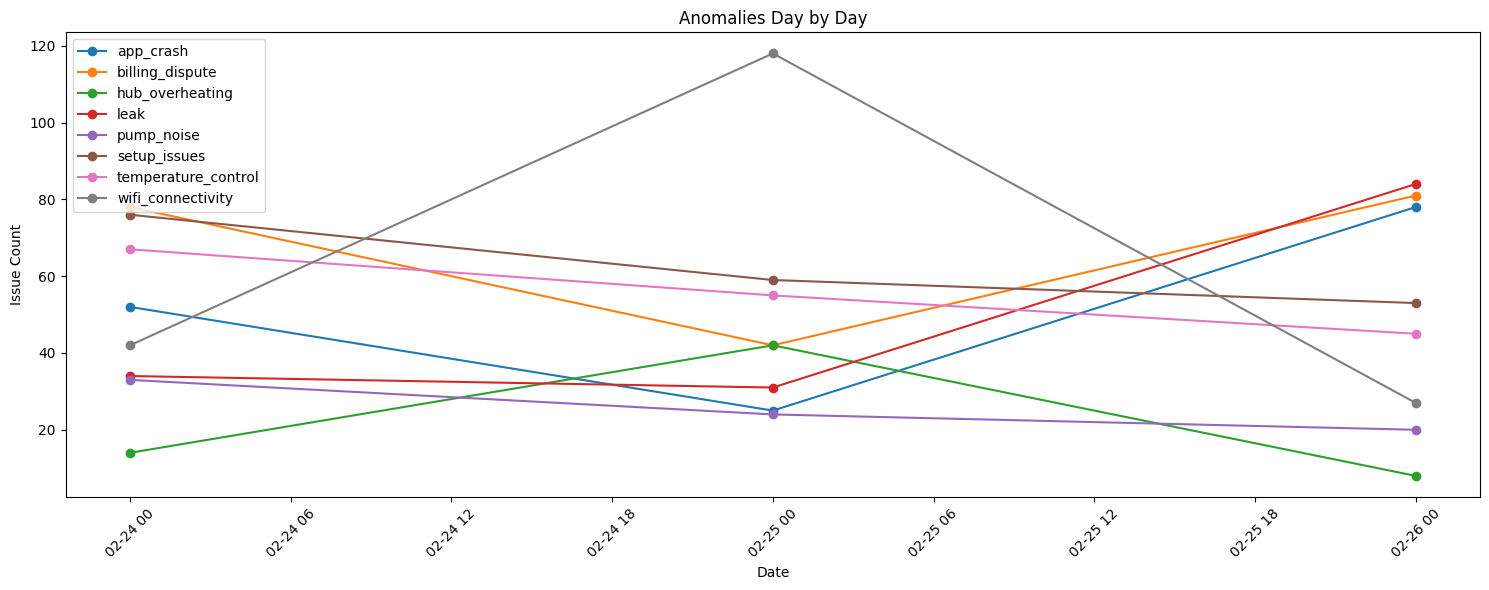

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert issue_date to datetime
df_anomalies['issue_date'] = pd.to_datetime(df_anomalies['issue_date'])

# Plot each issue_type
plt.figure(figsize=(15, 6))
for issue_type, group in df_anomalies.groupby('issue_type'):
    plt.plot(group['issue_date'], group['issue_count'], label=issue_type, marker='o')

plt.xlabel('Date')
plt.ylabel('Issue Count')
plt.title('Anomalies Day by Day')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
with duckdb.connect('../pipelines/duckdb/dev.duckdb') as con:
  df_anomalies_detected = con.sql('''
    select * from cx.vw_anomalies
  ''').df()
  display(df_anomalies_detected)


,issue_date,issue_type,priority,issue_count,yesterdays_count,day_over_day_change,baseline_change,spike_from_yesterday,spike_from_baseline
0,2026-02-25,hub_overheating,high,42.0,14.0,2.00,0.50,True,True
1,2026-02-25,wifi_connectivity,medium,118.0,42.0,1.81,0.48,True,False
2,2026-02-26,app_crash,medium,78.0,25.0,2.12,1.03,True,True
3,2026-02-26,billing_dispute,medium,81.0,42.0,0.93,0.35,True,False
4,2026-02-26,leak,high,84.0,31.0,1.71,1.58,True,True


In [25]:
if not df_anomalies_detected.empty:
    for i, row in df_anomalies_detected.iterrows():
        priority = row["priority"]
        issue_type = row["issue_type"]
        baseline = row["baseline_change"] * 100
        yesterday = row["day_over_day_change"] * 100
        print(f"""
            Hi team it looks like some {priority} priority items related to the issue type: `{issue_type}` have seen a {baseline}% change from the baseline and a {yesterday}% change from yesterdays issue count.
        """)


            Hi team it looks like some high priority items related to the issue type: `hub_overheating` have seen a 50.0% change from the baseline and a 200.0% change from yesterdays issue count.
        

            Hi team it looks like some medium priority items related to the issue type: `wifi_connectivity` have seen a 48.0% change from the baseline and a 181.0% change from yesterdays issue count.
        

            Hi team it looks like some medium priority items related to the issue type: `app_crash` have seen a 103.0% change from the baseline and a 212.0% change from yesterdays issue count.
        

            Hi team it looks like some medium priority items related to the issue type: `billing_dispute` have seen a 35.0% change from the baseline and a 93.0% change from yesterdays issue count.
        

            Hi team it looks like some high priority items related to the issue type: `leak` have seen a 158.0% change from the baseline and a 171.0% change from yesterdays 